In [24]:
# Basic imports and setup
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from analyze_modules import load_parameter_sweep
from analyze_modules.plot_utils import _get_scalar_data

# get viridis colormap
cmap = plt.get_cmap('viridis')
cmap.set_bad(color='black')
plt.rcParams['figure.dpi'] = 200

In [25]:
# habitability params
T_freeze = 273.15 # K
T_boil = np.array([100, 180, 310]) # deg C for P = [1, 10, 100] bar
T_boil = T_boil + T_freeze # K
P_boil = np.array([1, 10, 100]) # bar

In [26]:
# Parameters
P0s = np.array([1e6, 1e7, 1e8])
Tints = np.array([50, 75, 100, 125, 150, 200, 250])
CplusOs = np.array([1e-3, 1e-2, 1e-1])
CtoOs = np.array([0.1, 0.59, 1.0])
planets = np.array(['Earth', 'Io'])
adds = ['', '_aN=1e-4', '_aN=1e-2']
folder = '../output/EqCond+Remove/'

In [27]:
# Load the data by performing sweeps inside a loop

loop_over = planets # e.g. planets or N abundances
# ! adjust fixed parameters accordingly

tsurfs = np.zeros((len(loop_over), len(P0s), len(Tints)))

i_CplusO = 1
i_CtoO = 1

for i_loop, loop_name in enumerate(loop_over):
    for i_P0, p0_val in enumerate(P0s):
        
        fixed_params = {
            'planet': loop_name,
            'add': adds[0],
            'P0': p0_val,
            'CplusO': CplusOs[i_CplusO],
            'CtoO': CtoOs[i_CtoO]
        }
        
        # Perform a sweep over internal temperature
        run_list = load_parameter_sweep(
            folder,
            fixed_params=fixed_params,
            varying_param_name='Tint',
            varying_param_values=Tints
        )

        #print([run.iterations_read for run in run_list])
        
        # Extract the surface temperature from each run
        # This uses the helper function from plot_utils internally for consistency
        surf_temps = [_get_scalar_data(run, 't_surf', 0) for run in run_list]
        tsurfs[i_loop, i_P0, :] = surf_temps

print(np.sum(np.isnan(tsurfs)), 'of', np.prod(tsurfs.shape))

No valid data found for run Earth_P0=1e6_Tint=50_CplusO=1e-2_CtoO=0.59
No valid data found for run Earth_P0=1e6_Tint=75_CplusO=1e-2_CtoO=0.59
No valid data found for run Earth_P0=1e6_Tint=125_CplusO=1e-2_CtoO=0.59
No valid data found for run Earth_P0=1e8_Tint=200_CplusO=1e-2_CtoO=0.59
No valid data found for run Earth_P0=1e8_Tint=250_CplusO=1e-2_CtoO=0.59
No valid data found for run Io_P0=1e6_Tint=50_CplusO=1e-2_CtoO=0.59
No valid data found for run Io_P0=1e6_Tint=75_CplusO=1e-2_CtoO=0.59
No valid data found for run Io_P0=1e6_Tint=125_CplusO=1e-2_CtoO=0.59
No valid data found for run Io_P0=1e8_Tint=200_CplusO=1e-2_CtoO=0.59
No valid data found for run Io_P0=1e8_Tint=250_CplusO=1e-2_CtoO=0.59
10 of 42


In [28]:
def set_white(ax):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.tick_params(axis='x', colors='white', which='both')  # Set color for both major and minor ticks
    ax.tick_params(axis='y', colors='white', which='both')  # Set color for both major and minor ticks

    try: # if colorbar is present
        ax.images[0].colorbar.ax.yaxis.label.set_color('white')
        ax.images[0].colorbar.ax.tick_params(axis='y', colors='white', which='both')
        ax.images[0].colorbar.outline.set_color('white')
    except:
        pass

def increase_size(ax, linewidth=3, fontsize=14, legendcols=1, legendloc='best'):
    for l in ax.lines:
        l.set_linewidth(linewidth)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(linewidth)
    ax.xaxis.set_tick_params(width=linewidth)
    ax.yaxis.set_tick_params(width=linewidth)
    ax.xaxis.label.set_size(fontsize)
    ax.yaxis.label.set_size(fontsize)
    ax.xaxis.set_tick_params(labelsize=fontsize)
    ax.yaxis.set_tick_params(labelsize=fontsize)
    if legendloc != 'no':
        ax.legend(fontsize=fontsize, ncols=legendcols, loc=legendloc)

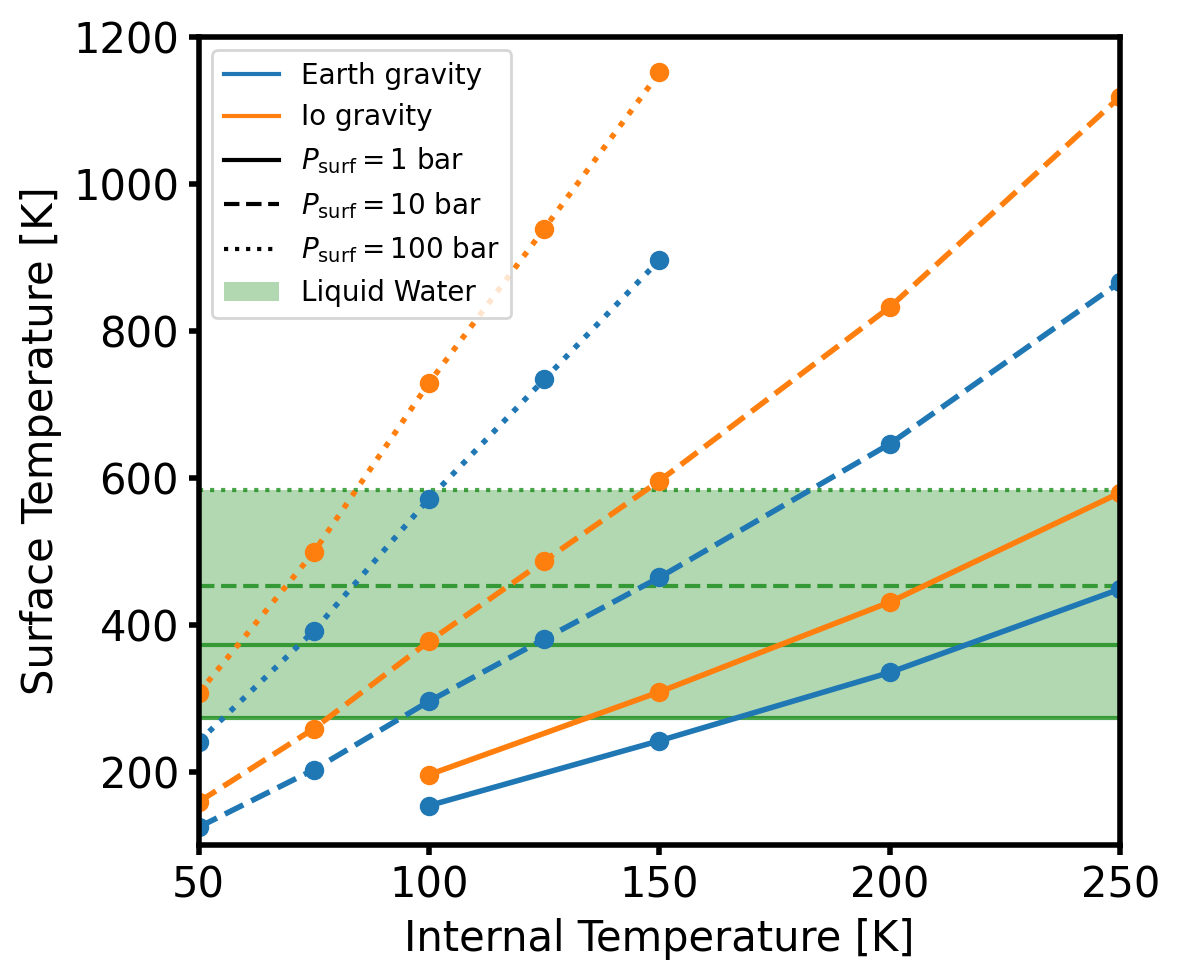

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
linestyles = ['o-', 'o--', 'o:']
colors = ['tab:blue', 'tab:orange']#, 'tab:red']

#for i, planet_name in enumerate(planets):
for i_loop, loop_name in enumerate(loop_over):
    for i_P0, p0_val in enumerate(P0s):
        mask = ~np.isnan(tsurfs[i_loop, i_P0, :])
        ax.plot(
            Tints[mask], 
            tsurfs[i_loop, i_P0, mask], 
            linestyles[i_P0], 
            color=colors[i_loop],
            label=None #f'{planet_name}, {p0_val/1e6:g} bar'
        )

xmin = 50
plt.hlines(T_freeze, xmin, Tints[-1], color='green', alpha=0.7, zorder=0)
plt.fill([xmin, xmin, Tints[-1], Tints[-1]], [T_boil[-1], T_freeze, T_freeze, T_boil[-1]], 'green', alpha=0.3, label='Liquid Water', zorder=-5)
for i_P0 in range(len(P0s)):
    plt.hlines(T_boil[i_P0], xmin, Tints[-1], color='green', linestyle=linestyles[i_P0][1:], alpha=0.7, zorder=0)

ax.set_xlim(50, 250)
ax.set_ylim(100, 1200)
ax.set_xlabel('Internal Temperature [K]')
ax.set_ylabel('Surface Temperature [K]')

lgd = ax.legend()

handles, labels = ax.get_legend_handles_labels()
for i in range(len(colors)):
    handles.append(plt.Line2D([0], [0], color=colors[i]))
    labels.append(planets[i] + ' gravity')
    #labels.append(r'$X_\mathrm{N}$ = 0.0' if adds[i] == '' else (r'$X_\mathrm{N}$ = ' + f'{adds[i][-4:]}'))
    #labels.append(r'$X_\mathrm{C+O}$ = ' + f'{CplusOs[i]}')
for i in range(len(linestyles)):
    handles.append(plt.Line2D([0], [0], linestyle=linestyles[i][1:], color='black'))
    labels.append(r'$P_\mathrm{surf}=$' + f'{P0s[i]*1e-6:.0f} bar')
handles.append(handles[0])
labels.append(labels[0])
handles = handles[1:]
labels = labels[1:]
#print(len(handles), labels)
lgd = ax.legend(handles, labels, loc='upper left', fontsize=10)


# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=2, fontsize=15, legendloc='no')
#ax.set_ylabel('')
plt.tight_layout()
#plt.savefig(f"images/JulyPoster/CompareGravity_CplusO={CplusOs[i_CplusO]}_CtoO={CtoOs[i_CtoO]}.svg", format="svg", transparent=True)

plt.show()

In [30]:
# Calculate internal temperature where surface temperature is equal to freezing point

loop_overs = planets

Tints_freeze = np.zeros((len(loop_overs), len(P0s)))
Tints_boil = np.zeros((len(loop_overs), len(P0s)))

for i_P0 in range(len(P0s)):
    for i, loop_over in enumerate(loop_overs):
        if np.isnan(tsurfs[i,i_P0,:]).all():
            continue
        mask = np.isnan(tsurfs[i,i_P0,:])
        Tsurf = tsurfs[i,i_P0,~mask]
        Tint = Tints[~mask]

        # interpolate Tsurf to find Tint
        f = interp1d(Tsurf, Tint, bounds_error=False, fill_value='extrapolate')
        Tint_freeze = f(T_freeze)
        Tint_boil = f(T_boil[i_P0])

        Tints_freeze[i,i_P0] = Tint_freeze
        Tints_boil[i,i_P0] = Tint_boil

        print(f'{loop_over} P0={P0s[i_P0]*1e-6:.0f} bar: Tint_freeze = {Tint_freeze:.2f} K')
        print(f'{loop_over} P0={P0s[i_P0]*1e-6:.0f} bar: Tint_boil = {Tint_boil:.2f} K')

print(np.average(Tints_freeze[1,:]/Tints_freeze[0,:]))

print((1821 / 6371)**(3/4))


Earth P0=1 bar: Tint_freeze = 166.57 K
Earth P0=1 bar: Tint_boil = 216.69 K
Io P0=1 bar: Tint_freeze = 134.18 K
Io P0=1 bar: Tint_boil = 176.35 K
Earth P0=10 bar: Tint_freeze = 93.86 K
Earth P0=10 bar: Tint_boil = 146.61 K
Io P0=10 bar: Tint_freeze = 78.03 K
Io P0=10 bar: Tint_boil = 117.29 K
Earth P0=100 bar: Tint_freeze = 55.32 K
Earth P0=100 bar: Tint_boil = 101.80 K
Io P0=100 bar: Tint_freeze = 45.57 K
Io P0=100 bar: Tint_boil = 84.16 K
0.8202062764967631
0.3909099776119995


In [31]:
# connect Tsurf to time evolution

# read in T_eff data from data/T_eff.dat (format: index, time, T_eff, a_moon, e_moon)
T_eff = np.loadtxt('../../FFP-Exomoons/output_Teff.out')
print(T_eff.shape)

n_time = 1000 #int(1000/10 + 1)

T_eff = T_eff.reshape((-1,n_time,5))
print(T_eff.shape)
print(T_eff[2,:,0].astype(int))

(6945000, 5)
(6945, 1000, 5)
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 

Time t = 1992.1375364285097
> inf K: 0 out of 6945


Text(0.5, 1.0, 'T_eff at t=1992 Myr')

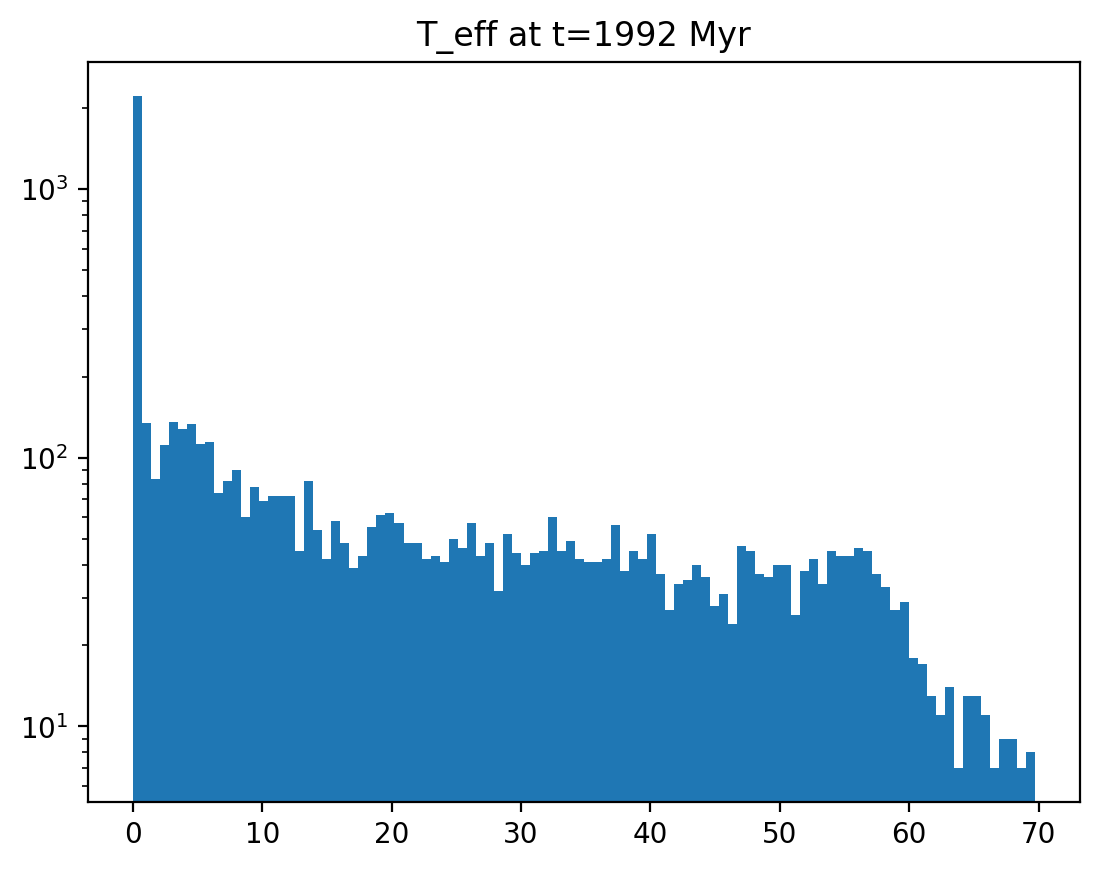

In [32]:
time = 2000 # Myr
i_time = np.argmin(np.abs(T_eff[0,:,1] - time))
print('Time t =', T_eff[0,i_time,1])

plot_T_eff = T_eff[:,i_time,2]

T_max = np.inf
T_eff_mask = plot_T_eff < T_max
print(f'> {T_max} K:', np.sum(~T_eff_mask), 'out of', len(plot_T_eff))
plot_T_eff = plot_T_eff[T_eff_mask]


plt.hist(plot_T_eff, bins=100, log=True)
plt.title(f'T_eff at t={T_eff[0,i_time,1]:.0f} Myr')

In [33]:
# calculate time spent in the habitable zone

t_minmax = np.zeros((len(loop_overs), len(P0s), T_eff.shape[0], 2))
time_habitable = np.zeros((len(loop_overs), len(P0s), T_eff.shape[0], 1))
switches = np.zeros((len(loop_overs), len(P0s), T_eff.shape[0]))

dt = np.zeros(T_eff.shape[1]+1)
dt[1:-1] = (T_eff[0,:-1,1] + T_eff[0,1:,1])/2
dt[0] = T_eff[0,0,1]
dt[-1] = T_eff[0,-1,1]
dt = dt[1:] - dt[:-1]

for i in range(len(loop_overs)):
    for i_p, P in enumerate(P0s):

        habitable = np.zeros(T_eff.shape[:2], dtype=bool)

        for i_t in range(n_time):
            T_eff_i = T_eff[:, i_t, 2]
            T_surf_i = np.interp(T_eff_i, Tints, tsurfs[i, i_p, :])

            habitable[:,i_t] = np.logical_and(T_surf_i >= T_freeze, T_surf_i <= T_boil[i_p])

        switch = np.diff(habitable.astype(int), axis=1)
        switches[i,i_p,:] = np.sum(switch == -1, axis=1)

        for i_moon in range(T_eff.shape[0]):
            time_habitable[i,i_p,i_moon,0] = np.sum(dt[habitable[i_moon,:]])

        # EXTRA TEST STUFF
        # habitable_test = np.zeros(T_eff.shape[0], dtype=bool)
        # for i_t in range(n_time):
        #     T_eff_i = T_eff[:, i_t, 2]
        #     T_surf_i = np.interp(T_eff_i, Tints, tsurfs[i, i_p, :])
        #     mask = np.logical_and(T_surf_i >= T_freeze, T_surf_i <= T_boil[i_p])
        #     if np.any(mask):
        #         mask = np.logical_and(~habitable_test, mask)
        #         t_minmax[i, i_p, mask, 0] = T_eff[mask, i_t, 1]
        #         habitable_test[mask] = True

        #     mask = np.logical_and(habitable_test, ~mask)
        #     if np.any(mask):
        #         t_minmax[i, i_p, mask, 1] = T_eff[mask, i_t, 1]
        #         habitable_test[mask] = False


time_habitable = time_habitable[:,:,:,0]
print(time_habitable[time_habitable!=0.0].min(), time_habitable.max())
print(time_habitable.shape)


# print(t_minmax.min(), t_minmax.max())
# time_habitable_test = t_minmax[:, :, :, 1] - t_minmax[:, :, :, 0]
# print(time_habitable_test[time_habitable_test!=0.0].min(), time_habitable_test.max())
# print(time_habitable_test.shape)

# time_habitable = time_habitable_test

0.004631673639563738 9999.268127999767
(2, 3, 6945)


Habitability for an Earth atmosphere
for P0 = 1 bar: 1401 out of 6945 or 20.2% reach the HZ
min: 0.004631673639563738 max: 95.74556403273216
argmin: 1839 argmax: 6250
for P0 = 10 bar: 2131 out of 6945 or 30.7% reach the HZ
min: 0.019762180577331367 max: 698.6403064842376
argmin: 4222 argmax: 2135
for P0 = 100 bar: 2984 out of 6945 or 43.0% reach the HZ
min: 0.0201299536873063 max: 4340.684054855384
argmin: 4222 argmax: 241


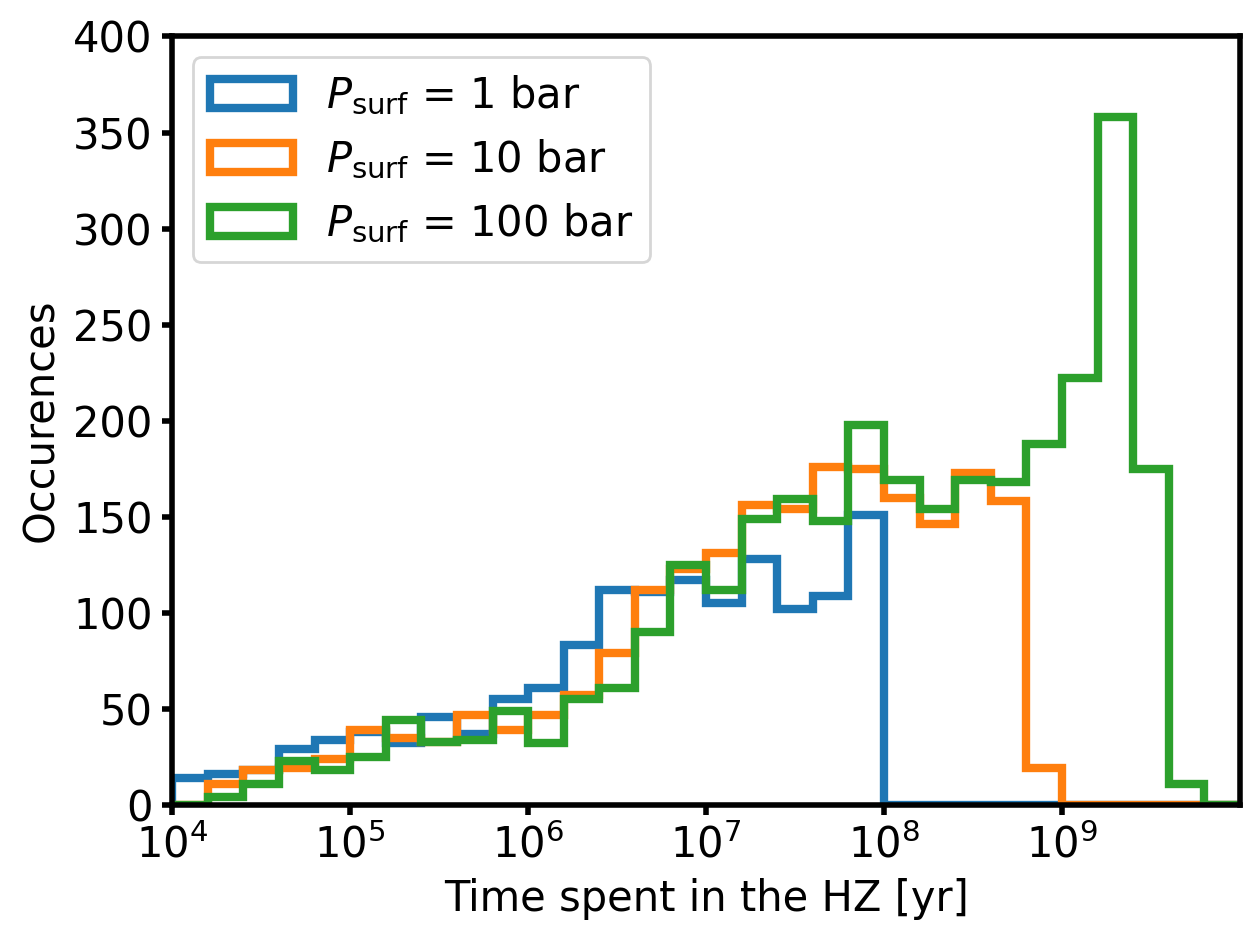

In [39]:
i_loop = 0

hist_min = 4 - 6
hist_max = 10 - 6

print(f'Habitability for an {loop_overs[i_loop]} atmosphere')
for i_p, P in enumerate(P0s):
    mask = time_habitable[i_loop, i_p, :] > 0

    #mask = np.logical_and(mask, switches[i_loop, i_p, :] == 2)

    print(f'for P0 = {P*1e-6:g} bar:', np.sum(mask), 'out of', len(mask), f'or {np.sum(mask)/len(mask)*100:.1f}% reach the HZ')
    min_time, max_time = time_habitable[i_loop, i_p, mask].min(), time_habitable[i_loop, i_p, :].max()
    print('min:', min_time, 'max:', max_time)
    print('argmin:', np.where(time_habitable[i_loop, i_p, :] == min_time)[0][0], 'argmax:', np.where(time_habitable[i_loop, i_p, :] == max_time)[0][0])
    plt.hist(np.log10(time_habitable[i_loop, i_p, mask]), bins=np.linspace(hist_min, hist_max, 31), label=r'$P_\mathrm{surf}$ = ' + f'{P*1e-6:g} bar', histtype='step', linewidth=3)

plt.xticks(np.arange(hist_min, hist_max, 1), [r'$10^{i}$'.format(i=i) for i in np.arange(hist_min, hist_max, 1)+6])
plt.xlim(hist_min, hist_max)
plt.ylim(0,400)

#.title(f'{i_param.replace('plus', '+').replace('to', '/')} = {loop_overs[i_loop]:.0e} atmosphere')
#plt.title(f'{loop_overs[i_loop][1:]} atmosphere')
plt.xlabel('Time spent in the HZ [yr]')
plt.ylabel('Occurences')

plt.legend()

if True:
    plt.title('')
    #set_white(plt.gca())
    increase_size(plt.gca(), linewidth=2, fontsize=15, legendloc='upper left')

    plt.tight_layout()

    #plt.ylabel('')
    #plt.gca().set_yticklabels([])

    plt.savefig(f'images/Paper1/TimeInHZ_CplusO={CplusOs[i_CplusO]:.0e}_CtoO={CtoOs[i_CtoO]:g}{adds[i_loop]}.pdf')#, transparent=True)

In [58]:
# get index with the maximum time spent in the HZ
max_index = np.argmax(time_habitable[i_loop, :, :], axis=-1)
print(max_index, time_habitable.shape)
for i, max_ind in enumerate(max_index):
    print(f'Maximum time spent in the HZ: {np.max(time_habitable[i_loop, i, max_ind])} yr for P0 = {P0s[i]*1e-6:.0f} bar')
    print(f'Index: {max_ind}, T_eff_init: {T_eff[max_ind, 0, 2]:.0f} K')
    # print the initial semi-major axis and eccentricity
    #print(f'Initial a_moon: {T_eff[max_ind, 0, 3]:.0f} cm, e_moon: {T_eff[max_ind, 0, 4]:.2f}')
    # print tminmax
    # print(t_minmax[i_loop, i, max_ind, :])

[6250 2135  241] (2, 3, 6945)
Maximum time spent in the HZ: 95.74556403273216 yr for P0 = 1 bar
Index: 6250, T_eff_init: 166 K
Maximum time spent in the HZ: 698.6403064842376 yr for P0 = 10 bar
Index: 2135, T_eff_init: 94 K
Maximum time spent in the HZ: 4340.684054855384 yr for P0 = 100 bar
Index: 241, T_eff_init: 56 K


698.6403064842376


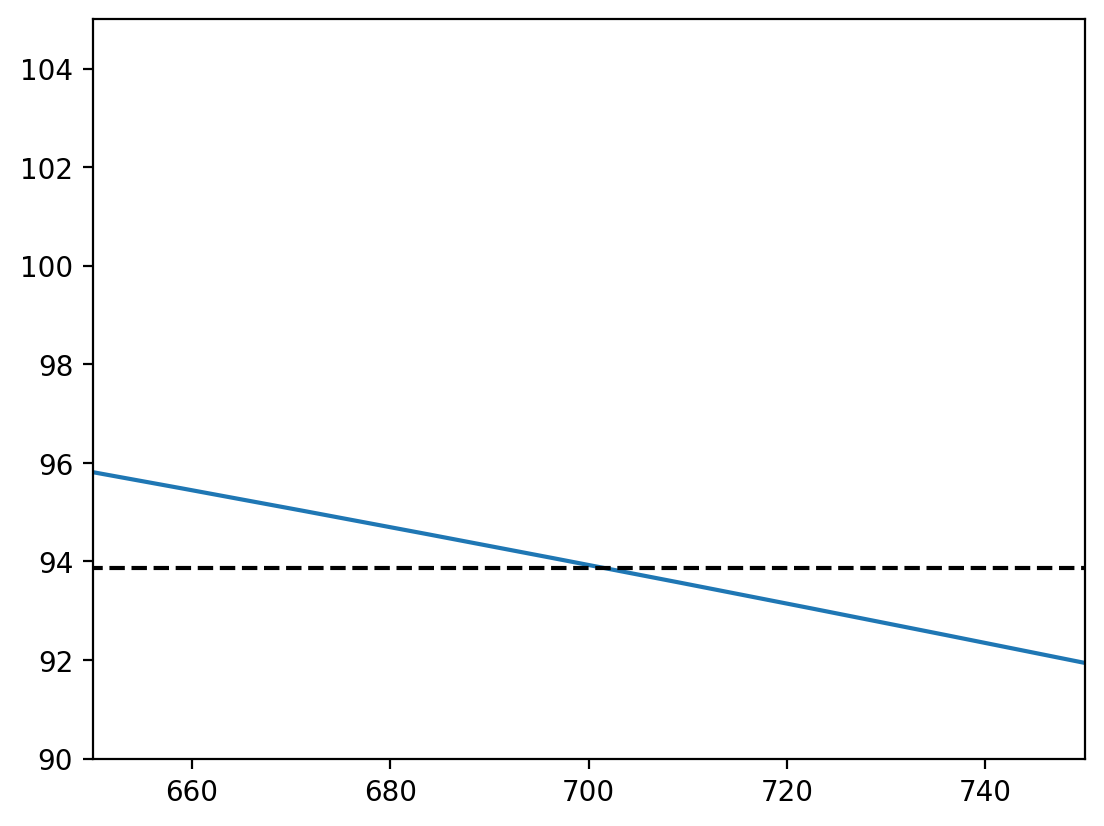

In [57]:
i_example = 2135
i_p = 1

print(time_habitable[i_loop,i_p,i_example])

plt.plot(T_eff[i_example,:,1], T_eff[i_example,:,2])

plt.hlines(Tints_freeze[i_loop,i_p], T_eff[i_example,:,1].min(), T_eff[i_example,:,1].max(), color='k', linestyle='--')
plt.hlines(Tints_boil[i_loop,i_p], T_eff[i_example,:,1].min(), T_eff[i_example,:,1].max(), color='k', linestyle='--')

#plt.xscale('log')
plt.xlim(6.5e2, 7.5e2)
plt.ylim(90, 105)

plt.show()


Text(0, 0.5, 'Eccentricity')

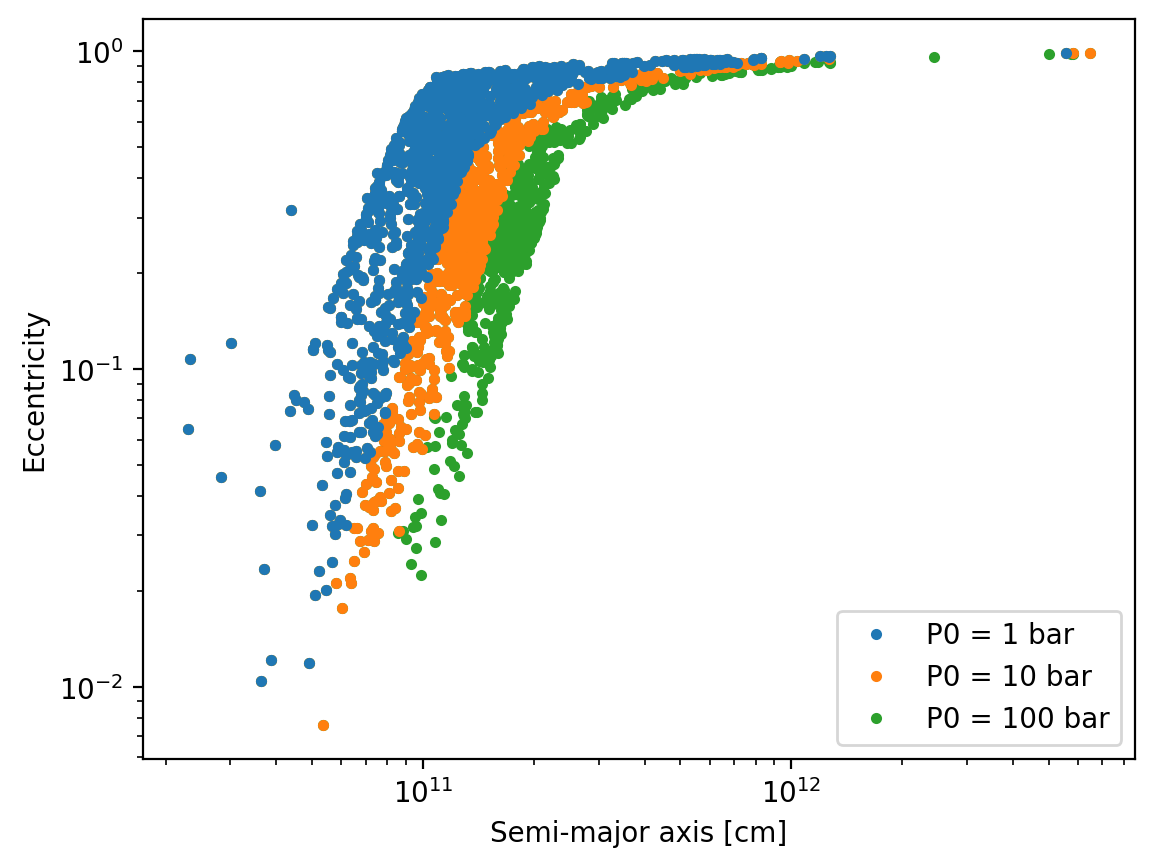

In [36]:
# track HZ back to inital semi-major axis

habitable_mask = time_habitable[i_loop, :, :] > 0

for i_p, P in enumerate(P0s[::1]):
    habitable_mask_iP = habitable_mask[i_p,:]
    
    a_habitable = T_eff[habitable_mask_iP,0,3]
    e_habitable = T_eff[habitable_mask_iP,0,4]

    plt.plot(a_habitable, e_habitable, '.', label=f'P0 = {P*1e-6:.0f} bar', zorder=-i_p)

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.xlabel('Semi-major axis [cm]')
plt.ylabel('Eccentricity')